In [6]:
import numpy as np
from scipy.integrate import odeint
from scipy.optimize import minimize
import time

# --------------------------------------------------------------------------
# Modelos da Planta e do Tanque
# --------------------------------------------------------------------------
def jacketed_tank(x, t, u, m):
    L, T = x
    #Fin, Q = u
    Fi, Fv = u

    # Importando parâmetros
    At  = m['At']
    k   = m['k']
    rho = m['rho']
    Cp  = m['Cp']
    lmb = m['lambda']
    Ti  = m['Ti']

    f1 = (Fi - k * np.sqrt(L) )/ At
    f2 = (rho * Fi * Cp * (Ti - T) + Fv * lmb) / (rho * At * L * Cp)
    f = [f1 , f2]
    
    return f


- Diferente do MATLAB, na integração $odeint$ a ordem dos argumentos é (função, condições_iniciais, tempo, args).

In [7]:
import numpy as np

# --------------------------------------------------------------------------
# Função Objetivo do NMPC
# --------------------------------------------------------------------------
def fob_NMPC(du, uk_1, Hp, Hc, ysp, q, r, Ts, x0m, x0, nu, ny, modelo):
    du = du.reshape((Hc, nu))
    J = 0
    x_sim = x0m.copy()
    u_atual = uk_1.copy()
    bias = x0 - x0m

    for i in range(Hp):
        if i < Hc:
            u_atual = u_atual + du[i, :]
        
        # Simulação de 1 passo à frente
        t_span = [0, Ts]
        res = odeint(jacketed_tank, x_sim, t_span, args=(u_atual, modelo))
        x_sim = res[-1, :]
        #print(x_sim)
        # Saída predita com correção de bias
        y_hat = x_sim + bias
        
        # Custo: Erro do Setpoint + Esforço de controle (Delta U)
        error = y_hat - ysp
        # print(f'Erro', error.shape)
        J += np.dot(error, np.dot(np.diag(q), error))
        
        if i < Hc:
            J += np.dot(du[i, :], np.dot(np.diag(r), du[i, :]))
            
    return J


In [8]:
import numpy as np

# --------------------------------------------------------------------------
# Parâmetros e Configurações
# --------------------------------------------------------------------------
modelo = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}
modelo_p = {'rho': 1e3, 'Cp': 4.18, 'At': np.pi*0.5**2, 'k': 7, 'lambda': 2.257e4, 'Ti': 40}

nsim = 200
Hp, Hc = 10, 2
q = np.array([10, 10])
r = np.array([0.1, 0.1])
Ts = 0.1
nu, ny = 2, 2

# Restrições
umin = np.array([5, 5])
umax = np.array([25, 30])
dumax = np.array([1, 2])

# Condições iniciais
uk_1 = np.array([10.0, 10.0])
x0 = np.array([2.0408, 45.4])
x0m = x0.copy()
du0 = np.zeros(Hc * nu)

# Armazenamento de dados
history = {'yp': [], 'uk': [], 'sp': [], 'J': [], 'tcalc': [], 'nint': []}

- Otimização $minimize$: O SLSQP do Python é excelente, mas é ideal que o chute inicial (du0) seja razoável.

- $minimize$ argumentos: (fun, x0, args=(), method=None, jac=None, hess=None, hessp=None, bounds=None, constraints=(), tol=None, callback=None, options=None).

OBS: constraints determina restrições de igualdades e desigualdades.
A lógica é: $u_{min} \leq u_{k-1} + \sum \Delta u \leq u_{max}$
- $minimize$ retorna:

In [9]:
import numpy as np
    
# --------------------------------------------------------------------------
# Loop de Simulação
# --------------------------------------------------------------------------
for k in range(nsim):
    if(k<20):
        ysp = np.array([3.0, 50.0])
    if(20 < k < 100):
        ysp = np.array([2.5, 47.0])
    if(k>100):
        ysp = np.array([4.0, 48.0])

    # Restrições para o otimizador
    bounds = [(-dumax[i%nu], dumax[i%nu]) for i in range(Hc*nu)]
    constraints = {
    'type': 'ineq', 
    'fun': lambda du, uk_1, umin, umax: np.array([
        # Isso substitui o Bin = @(uk_1) [repmat(umax...)]
        *[(umax - (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0))).flatten() for i in range(Hc)],
        *[( (uk_1 + np.sum(du.reshape(Hc, nu)[:i+1, :], axis=0)) - umin).flatten() for i in range(Hc)]
    ]).flatten(),
    'args': (uk_1, umin, umax)
    }
    
    start_time = time.time() # 1 Marca o tempo de início
    res = minimize(fob_NMPC,
                   du0,
                   args=(uk_1, Hp, Hc, ysp, q, r, Ts, x0m, x0, nu, ny, modelo_p),
                   method='SLSQP', 
                   bounds=bounds,
                   constraints=constraints)
    history['nint'].append(res.nit)
    history['tcalc'].append(time.time() - start_time) # 2 Calcula a diferença
    
    du_opt = res.x.reshape((Hc, nu))
    uk_atual = uk_1 + du_opt[0, :]
    
    # Planta (Simulação real)
    mult = 1 if k < 80 else 1.1
    u_planta = uk_atual * mult
    x_next_p = odeint(jacketed_tank, x0, [0, Ts], args=(u_planta, modelo))[-1, :]
    
    # Modelo (Simulação interna do controlador)
    x_next_m = odeint(jacketed_tank, x0m, [0, Ts], args=(uk_atual, modelo_p))[-1, :]
    
    # Atualização
    history['yp'].append(x_next_p)
    history['uk'].append(uk_atual)
    history['sp'].append(ysp)
    history['J'].append(res.fun)
    
    x0, x0m, uk_1 = x_next_p, x_next_m, uk_atual
    du0 = np.concatenate([du_opt[1:], np.zeros((1, nu))]).flatten()

Tempo Máximo[s] =  0.09050941467285156 
Tempo Médio[s] =  0.02338283061981201 
Tempo Total[s] =  4.676566123962402


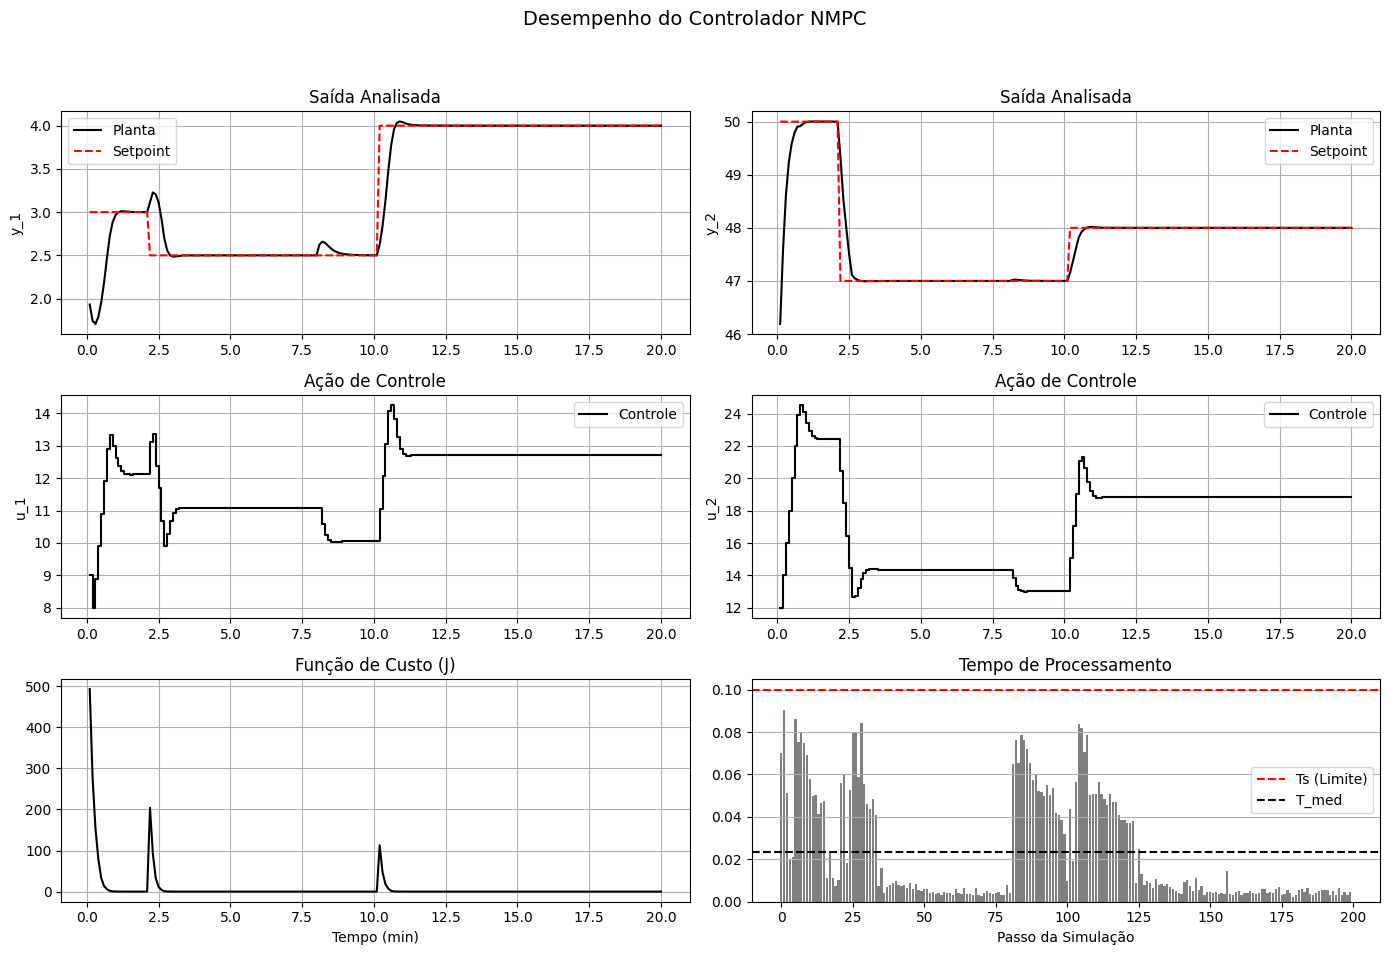

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# Gráficos
# --------------------------------------------------------------------------
history['yp'] = np.array(history['yp'])
history['uk'] = np.array(history['uk'])
history['sp'] = np.array(history['sp'])
history['cost'] = np.array(history['J'])
t_axis = np.linspace(Ts, nsim*Ts, nsim)

tempo_medio = np.mean(history['tcalc'])
tempo_max = np.max(history['tcalc'])
tempo_sum = np.sum(history['tcalc'])
print(f'Tempo Máximo[s] = ', tempo_max, '\nTempo Médio[s] = ', tempo_medio, '\nTempo Total[s] = ', tempo_sum)

fig, axs = plt.subplots(3, 2, figsize=(14, 10))
fig.suptitle('Desempenho do Controlador NMPC', fontsize=14)

# --- 1. SAÍDAS (y) ---
for i in range(ny):
    axs[0, i].plot(t_axis, history['yp'][:, i], 'k', label='Planta')
    axs[0, i].plot(t_axis, history['sp'][:, i], 'r--', label='Setpoint')
    axs[0, i].set_title(f'Saída Analisada')
    axs[0, i].set_ylabel(f'y_{i+1}')
    axs[0, i].grid(True)
    axs[0, i].legend()

# --- 2. ENTRADAS (u) ---
for i in range(nu):
    axs[1, i].step(t_axis, history['uk'][:, i], 'k', label='Controle', where='post')
    axs[1, i].set_title(f'Ação de Controle')
    axs[1, i].set_ylabel(f'u_{i+1}')
    axs[1, i].grid(True)
    axs[1, i].legend()

# --- 3. DESEMPENHO (Custo e Tempo) ---
# Gráfico de Custo
axs[2, 0].plot(t_axis, history['J'], 'k', label= 'Custo', linewidth=1.5)
axs[2, 0].set_title('Função de Custo (J)')
axs[2, 0].set_xlabel('Tempo (min)')
axs[2, 0].grid(True)

# Gráfico de Tempo de Cálculo
axs[2, 1].bar(range(nsim), history['tcalc'], color='k', alpha=0.5)
axs[2, 1].axhline(y=Ts, color='r', linestyle='--', label='Ts (Limite)')
axs[2, 1].axhline(y=tempo_medio, color='k', linestyle='--', label='T_med')
axs[2, 1].set_title('Tempo de Processamento')
axs[2, 1].set_xlabel('Passo da Simulação')
axs[2, 1].legend()
axs[2, 1].grid(axis='y')

# Ajuste fino para não sobrepor títulos e eixos
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()